# Explanatory Data Analysis

Importy potrzebnych bibliotek

In [70]:

import EDAhelperfunctions as EDAhelp
import pandas as pd
import numpy as np
from pathlib import Path

import seaborn as sns

import kagglehub

import pandas as pd


sns.set_theme(style="whitegrid")
np.random.seed(67)



Zapis datasetu

In [71]:
# pobranie datasetu

dataset_dir = Path(kagglehub.dataset_download("danizo/eeg-dataset-for-adhd"))
p = dataset_dir / "adhdata.csv"
df = pd.read_csv(p)


Kształt zbioru danych

In [72]:

print(df.shape)
print(df.groupby("ID").count())


(2166383, 21)
        Fp1    Fp2     F3     F4     C3     C4     P3     P4     O1     O2  \
ID                                                                           
v107  19794  19794  19794  19794  19794  19794  19794  19794  19794  19794   
v108  19026  19026  19026  19026  19026  19026  19026  19026  19026  19026   
v109  16044  16044  16044  16044  16044  16044  16044  16044  16044  16044   
v10p  14304  14304  14304  14304  14304  14304  14304  14304  14304  14304   
v110  16549  16549  16549  16549  16549  16549  16549  16549  16549  16549   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
v58p  13918  13918  13918  13918  13918  13918  13918  13918  13918  13918   
v59p  16513  16513  16513  16513  16513  16513  16513  16513  16513  16513   
v60p  12929  12929  12929  12929  12929  12929  12929  12929  12929  12929   
v6p   17561  17561  17561  17561  17561  17561  17561  17561  17561  17561   
v8p   15776  15776  15776  15776  15776  15776  15

Bilans klas

In [73]:
print(df['Class'].value_counts(normalize=True).round(2)*100)

Class
ADHD       56.0
Control    44.0
Name: proportion, dtype: float64


## Opis datasetu i struktury

Dane składają się z 21 kolumn oraz 2 166 383 wierszy.

19 kanałów to elektrody pobierające sygnał EEG, ID to identyfikator pacjenta ,co się zgadza z datasetem ( 121 wierszy)

Wiersze przedstawiają szeregi czasowe dla 121 prób, podczas których badano sygnały EEG u dzieci. Jednostką pomiaru był pV.

Klasa określa, czy dziecko ma ADHD, czy nie.

Uczestnicy to 61 dzieci z ADHD i 60 zdrowych kontrolnych (chłopcy i dziewczynki, w wieku 7-12 lat). Dzieci z ADHD zostały zdiagnozowane przez doświadczonego psychiatry zgodnie z kryteriami DSM-IV i przyjmowały Ritalin przez maksymalnie 6 miesięcy. Żadne z dzieci w grupie kontrolnej nie miało historii zaburzeń psychiatrycznych, epilepsji ani żadnych zgłoszeń ryzykownych zachowań.

Rejestracja EEG została wykonana zgodnie ze standardem 10-20 przy użyciu 19 kanałów (Fz, Cz, Pz, C3, T3, C4, T4, Fp1, Fp2, F3, F4, F7, F8, P3, P4, T5, T6, O1, O2) z częstotliwością próbkowania 128 Hz. Elektrody A1 i A2 były referencyjne, umieszczone na płatkach uszu.

Propocja danych z osób z ADHD do osób bez ADHD wynosi 55% do 44%

## Sanity check 

Wartości sygnałów ustawiamy na inty, class jako zmienną kategoryczną.



In [74]:

# dane numeryczne
numeric_cols = df.columns[:-2]

channels = list(numeric_cols)

df.loc[:, numeric_cols] = df.loc[:, numeric_cols].astype("int32")
df["Class"] = df["Class"].astype("category")

# częstotliwość próbkowania
fs = 128



W datasecie nie ma obserwacji brakujących

## Wizualizacja przykładowych danych

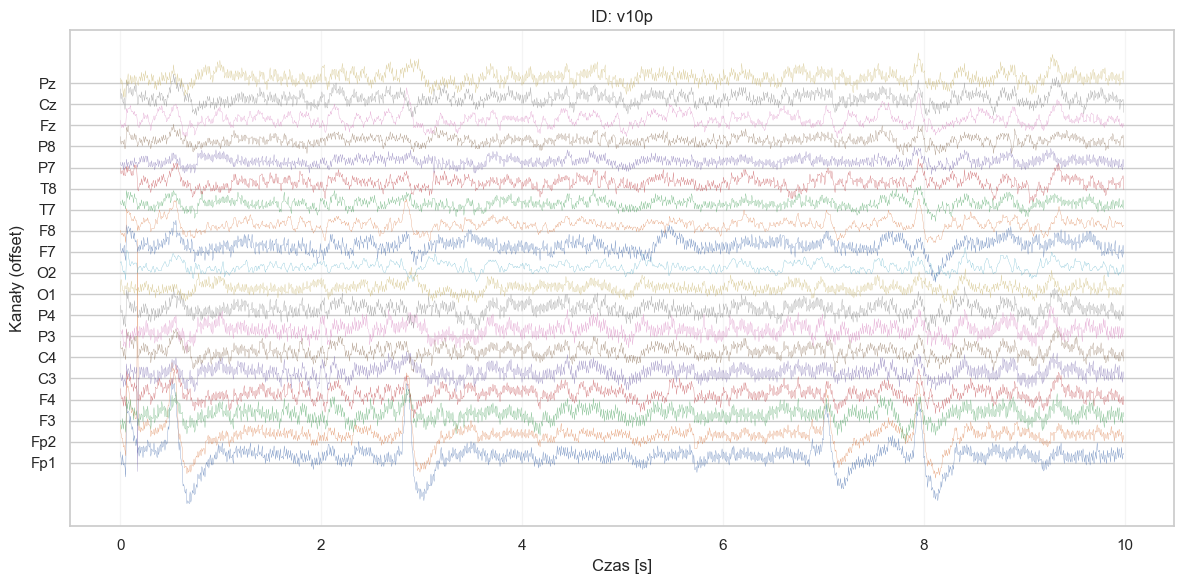

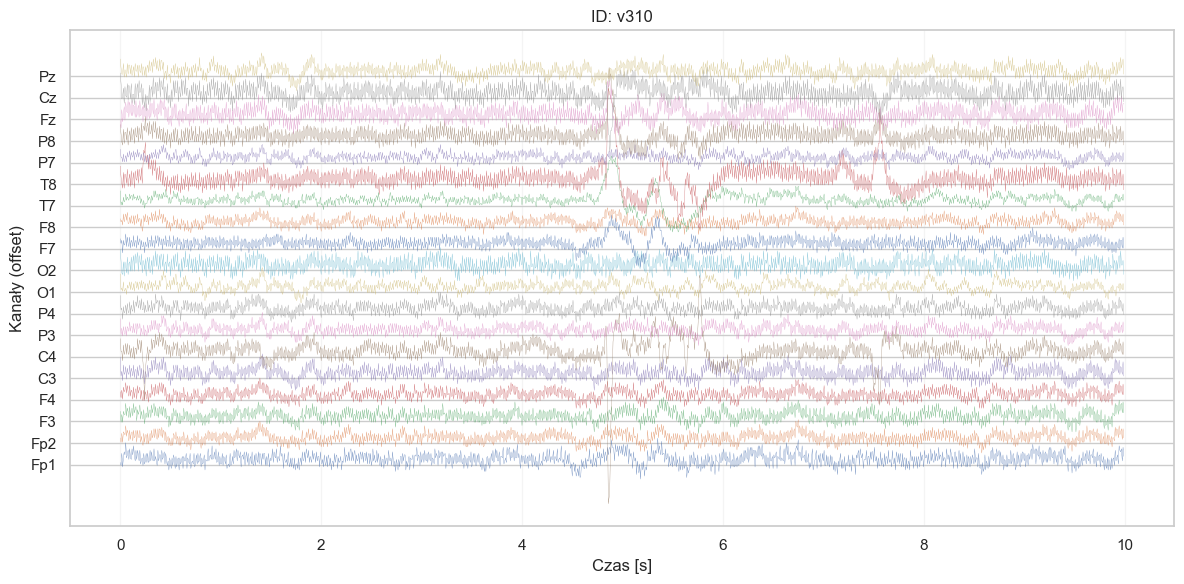

In [75]:
sample_ids = ["v10p","v310"]
for sid in sample_ids:
    EDAhelp.visualize_signals(df, sid, channels, 128, 10)

Dla przykładowych danych ,widać że w pierwszych 10 sekundach aktywność mózgu pacjenta z ADHD była wzmożona na początku i na końcu, natomiast dla pacjetna bez ADHD, aktywność była wzmożona bliżej środka tego okresu

## Usuwanie mniej ważnych kanałów

Stosujemy tutaj dwa filtry

 * Filtr 1
    - Dla każdej sesji `ID` liczymy wariancję dla poszczególnych kanałów \
    następnie bierzemy medianę tych wariancji, i jeżeli znajduje się ona ponieżej 20-tego percentyla, to uznajemy \
    wyniki tego kanału za mało wnoszące i nie uwzględniamy go w analizie. Uznajemy go za `płaski`
* Filtr 2
   - Dla każdej sesji `ID` liczymy korelację pomiędzy każdymi kanałami, następnie liczymy średnią korelację dla wszystkich sesji \
   oraz jej odchylenie standardowe. Jeżeli jeżeli, powstała średnia korelacja jest wystarczająco duża (u nas próg 0.7) oraz \
   odchylenie standardowe jest wystarczająco małe (próg 0.2) to usuwamy jedną z tych wysoko skorelowanych kanałów. \
   Uznajemy że nie wnosi żadnej nowej informacji do modelu.

In [76]:
df = EDAhelp.filtr_1(df, channels, low_var_q=0.20)
df = EDAhelp.filtr_2(df, channels=None, high_corr=0.7, std_thresh=0.2, top_k=20)

Kanały pozostałe po zastosowaniu filtrów

In [77]:
channels = (df.iloc[:,2:]).columns
print(channels)

Index(['Fp1', 'Fp2', 'F7', 'Fz', 'P3', 'F8', 'T7', 'O1', 'F4', 'O2', 'Pz',
       'Cz', 'T8'],
      dtype='str')


## Ekstrakcja dodatkowych cech

Ekstrakcja dodatkowych cech

*  Średnia / RMS / energia
    -   opisują ogólny poziom aktywacji i siłę sygnału; w ADHD różnice mocy (zwłaszcza delta/theta/alpha/beta) są szeroko raportowane i często stanowią bazę klasyfikatorów.  
*  Odchylenie standardowe, wariancja
    -   prosty wskaźnik zmienności kanału; niski “low-variance” kanał bywa artefaktem lub słabym elektrodą, a wysoka zmienność może nosić sygnał kliniczny.
* Skośność i kurtoza
    -   chwytają nieliniowości i “spiczastość” rozkładu; w EEG ADHD raportuje się zmiany kształtu rozkładów amplitud (nie‑gaussianity) i są używane m.in. w selekcji kanałów/feature’ów.
* Peaks (liczba pików)
    -   lokalne ekstrema pomagają wykrywać krótkie deflekcje / szpilki; w zestawach klinicznych bywa to prosty detektor artefaktów lub krótkich rozbłysków aktywności.
* Moc w pasmach delta/theta/alpha/beta
    -   klasyczny marker – liczne prace dla ADHD i innych zaburzeń opierają się na różnicach pasm; względna moc normalizuje na różne poziomy amplitudy.
* Entropia spektralna
    -   mierzy złożoność/rozproszenie widma; w nowszych pracach dla ADHD i innych zaburzeń (ASD, depresja) okazuje się jedną z najważniejszych cech – usunięcie obniża accuracy nawet o 30%.

Dlaczego wybrałem poniższe cechy? Jasnym jest, że nie mając wcześniejszej styczności z analizami tego typu, uznałem że dobrym pomysłem będzie spytanie chata, w jaki sposób analizować tego typu dane.
Ponieważ mamy tabelę szeregów czasowych, więc nie można jej analizować jako datebeli wartości ani pojedynczego szeregu czasowego. Trzeba porównywać te szeregi czasowe na podstawie jakiś ich charakterystycznych cech.
W źródłach poniżej, znajdują się artykuły wskazujące na pozytywny wpływ dodanych wskaźników, na zdolności modeli predykcyjnych, badających ludzi z ADHD oraz bez niego

In [78]:
features_df = EDAhelp.build_features(df, channels, fs)
print(features_df.shape)
display(features_df.head())

(121, 159)


,ID,Class,duration,Fp1_mean,Fp1_std,Fp1_skew,Fp1_kurt,Fp1_rms,Fp1_energy,Fp1_peaks,...,T8_skew,T8_kurt,T8_rms,T8_energy,T8_peaks,T8_delta_power,T8_theta_power,T8_alpha_power,T8_beta_power,T8_spectral_entropy
0,v107,Control,154.640625,135.460746,329.532878,-0.601913,31.260017,356.288551,2.512681e+09,6758,...,-1.078364,26.402861,290.076652,1.665556e+09,7499,0.524251,0.022997,0.008108,0.007495,8.465697
1,v108,Control,148.640625,130.880374,192.302712,-1.303729,32.338090,232.615575,1.029497e+09,6904,...,-1.566127,32.819411,255.379501,1.240851e+09,3915,0.605560,0.014578,0.010892,0.005733,7.843586
2,v109,Control,125.343750,138.053914,585.687398,-0.042285,3.961961,601.737992,5.809350e+09,2704,...,-0.408099,6.595363,462.913599,3.438053e+09,4025,0.513195,0.013865,0.008558,0.007507,8.806282
3,v10p,ADHD,111.750000,146.172399,223.934385,0.557182,8.439172,267.419107,1.022922e+09,5547,...,-0.170678,1.961420,212.211096,6.441599e+08,4999,0.615181,0.023173,0.033408,0.031527,6.278369
4,v110,Control,129.289062,140.691885,247.478648,0.004143,1.290301,284.675056,1.341129e+09,6444,...,-0.098578,1.639845,278.667937,1.285126e+09,6035,0.593694,0.011778,0.002788,0.004347,7.608774


Dlaczego takie dodatkowe wskaźniki?
Tutaj źródła:
 * https://pubmed.ncbi.nlm.nih.gov/34043150/
 * https://pubmed.ncbi.nlm.nih.gov/40179119/
 * https://pubmed.ncbi.nlm.nih.gov/27170672/
 * https://research.manchester.ac.uk/en/publications/eeg-power-spectral-slope-differs-by-adhd-status-and-stimulant-med/?utm_source=openai
 * http://expert.taylors.edu.my/file/rems/publication/109192_8910_1.pdf?utm_source=openai
 * https://mdpi-res.com/sensors/sensors-18-03743/article_deploy/sensors-18-03743.pdf?utm_source=openai


Srawdzenenie, czy wszystkie z dodatkowych cech są warte uwagi. Jako kryterium przyjmiemy 3 rzeczy. Wynik p_value testy Mann-Whitneya, effect_size oraz auc_sep . Jeżeli auc < 0.5 p_value > 0.05 oraz effect size < 0.1, to zmienną usuwamy

In [80]:
results_df = EDAhelp.rank_features_mannwhitney(features_df)
print(results_df.head(5))

          feature       p_value  effect_size   auc_sep     p_adj
0  Fz_theta_power  4.495437e-07     0.532240  0.766120  0.000071
1  Fz_alpha_power  1.236547e-06     0.511475  0.755738  0.000079
2  T7_delta_power  1.733034e-06     0.504372  0.752186  0.000079
3  P3_alpha_power  2.022204e-06     0.501093  0.750546  0.000079
4   Fz_beta_power  3.532576e-06     0.489071  0.744536  0.000089


Test Mann-Whitney wskazuje, że dla niektórych z policzonych wskaźników p-value jest znacznie większe od 0.05, co  świadczy o tym ,że możemy je usunąć, zostawiamy tylko te cechy dla któych p_value jest < 0.10>

In [81]:

features_df_filtered, keep_df, keep_feats, drop_feats = EDAhelp.filter_features_by_statistics(
    features_df=features_df,
    results_df=results_df,
    p_adj_threshold=0.10,
    effect_size_threshold=0.20,
    auc_threshold=0.60,
)

print(f"Zostawiam {len(keep_feats)} cech, usuwam {len(drop_feats)}")
print(keep_df[["feature", "p_value", "p_adj", "effect_size", "auc_sep"]].head(50))


Zostawiam 69 cech, usuwam 88
            feature       p_value     p_adj  effect_size   auc_sep
0    Fz_theta_power  4.495437e-07  0.000071     0.532240  0.766120
1    Fz_alpha_power  1.236547e-06  0.000079     0.511475  0.755738
2    T7_delta_power  1.733034e-06  0.000079     0.504372  0.752186
3    P3_alpha_power  2.022204e-06  0.000079     0.501093  0.750546
4     Fz_beta_power  3.532576e-06  0.000089     0.489071  0.744536
5    Fz_delta_power  3.808082e-06  0.000089     0.487432  0.743716
6            Pz_rms  4.533294e-06  0.000089    -0.483607  0.741803
7            Pz_std  4.647125e-06  0.000089    -0.483060  0.741530
8    Pz_delta_power  5.258575e-06  0.000089     0.480328  0.740164
9    P3_delta_power  5.661658e-06  0.000089     0.478689  0.739344
10   P3_theta_power  6.886277e-06  0.000098     0.474317  0.737158
11   F7_delta_power  7.589894e-06  0.000099     0.472131  0.736066
12           P3_std  9.896952e-06  0.000120    -0.466120  0.733060
13           P3_rms  1.256354e-05

Ostatnim krokiem filtracji cech, będzie jeszcze zbadanie korelacji tych co zostały i usunięcie cech redundatnych

In [83]:


# startujemy ze zbioru po wcześniejszym filtrowaniu
num_df = features_df_filtered.drop(columns=["ID", "Class"]).copy()

# macierz korelacji
corr = num_df.corr(method="spearman").abs()

# ranking jakości cech
feature_quality = results_df.set_index("feature")[["p_adj", "auc_sep"]]

to_drop = set()
cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]

        if corr.loc[f1, f2] > 0.80:
            q1 = feature_quality.loc[f1]
            q2 = feature_quality.loc[f2]

            # lepsza cecha = niższe p_adj, a przy remisie wyższe auc_sep
            if (q1["p_adj"] < q2["p_adj"]) or (
                q1["p_adj"] == q2["p_adj"] and q1["auc_sep"] >= q2["auc_sep"]
            ):
                to_drop.add(f2)
            else:
                to_drop.add(f1)

print("Usuwam", len(to_drop), "cech przez wysoką korelację")

features_df_corr_filtered = features_df_filtered.drop(columns=list(to_drop)).copy()
print(features_df_corr_filtered.shape)


Usuwam 25 cech przez wysoką korelację
(121, 46)


In [84]:

df = features_df_corr_filtered
print(df.columns.sort_values())


Index(['Class', 'Cz_alpha_power', 'Cz_beta_power', 'Cz_rms', 'Cz_theta_power',
       'F4_beta_power', 'F4_theta_power', 'F7_alpha_power', 'F7_beta_power',
       'F7_delta_power', 'F7_theta_power', 'F8_alpha_power', 'F8_beta_power',
       'F8_delta_power', 'F8_peaks', 'F8_theta_power', 'Fp1_alpha_power',
       'Fp1_beta_power', 'Fp1_delta_power', 'Fp1_spectral_entropy',
       'Fp1_theta_power', 'Fp2_alpha_power', 'Fp2_beta_power',
       'Fp2_spectral_entropy', 'Fp2_theta_power', 'Fz_alpha_power',
       'Fz_beta_power', 'Fz_delta_power', 'Fz_theta_power', 'ID',
       'O1_alpha_power', 'O1_beta_power', 'O2_alpha_power', 'O2_beta_power',
       'O2_rms', 'P3_theta_power', 'Pz_rms', 'T7_alpha_power', 'T7_beta_power',
       'T7_delta_power', 'T8_alpha_power', 'T8_beta_power', 'T8_delta_power',
       'T8_kurt', 'T8_theta_power', 'duration'],
      dtype='str')


Więc po wstępnej analizie, z jednego sygnału EEG możemy wyodrębnić 46 cech.

## Analiza rozkładów cech

Z racji tego że mamy dla każdego czujnika różną ilość cech, to poglądowo przedstawimy rozkłady jednej cechy dla każdego czujnika

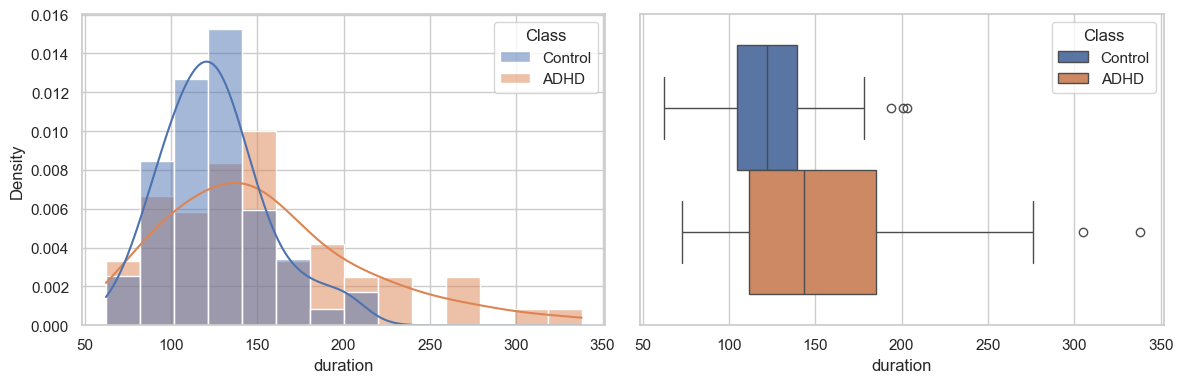

In [ ]:
EDAhelp.draw_plot(df,"duration")

Dla czasu trwania sesji widać znaczne przesunięcie w prawą stronę dla pacjentów ze stwierdzonym ADHD

Podobne obserwacje dla :Cz_alpha_power, Cz_beta_power, Cz_theta_power, F4_alpha_power, F4_beta_power, F4_theta_power, F7_alpha_power, F7_beta_power, F7_delta_power, F7_theta_power, F8_alpha_power, F8_beta_power\
F8_delta_power, F8_theta_power, Fp1_alpha_power, Fp1_beta_power, Fp1_delta_power, Fp1_spectral_entropy, Fp1_theta_power, Fp2_alpha_power, Fp2_beta_power, Fp2_spectral_entropy, Fp2_theta_power, Fz_alpha_power\
Fz_beta_power, Fz_delta_power, Fz_theta_power, O1_alpha_power, O1_beta_power, O2_alpha_power, O2_beta_power, 'P3_alpha_power, P3_beta_power, P3_delta_power, P3_theta_power, T7_alpha_power, T7_beta_power, T7_delta_power\
T8_alpha_power, T8_beta_power, T8_delta_power, T8_kurt, T8_theta_power

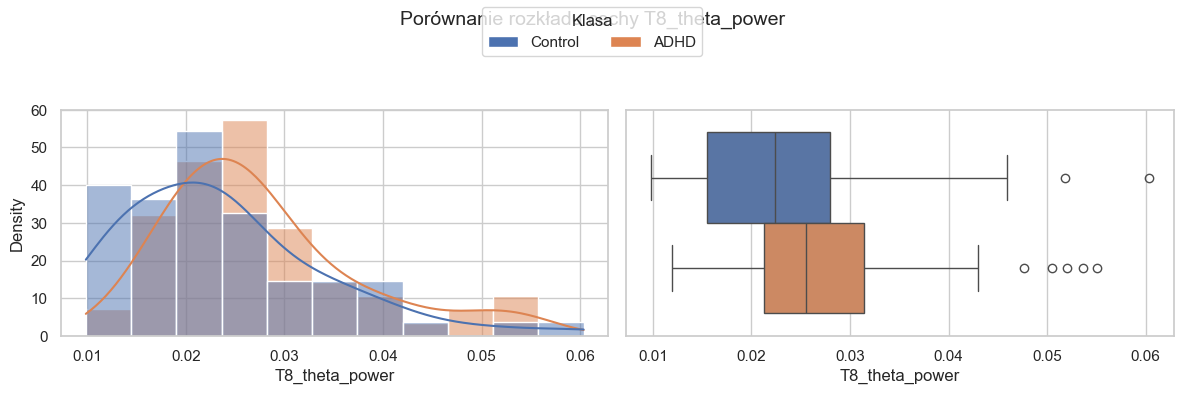

In [68]:
EDAhelp.draw_plot(df,"T8_theta_power")

Za to dla zmiennej Cz_peaks, przesunięcie jest odwrotne, osoby ze stwierdzonym ADHD, wykresy sugerują tendencję dla osó z ADHD do mniejszej wartości Cz_peaks

Podobne obserwacje dla: Cz_rms, F7_std, F8_peaks, Fp1_std, Fz_rms, O1_rms, O2_rms, Pz_rms

Przykładowy pairplot, obrazujący zmianyt względem klas poszczególnych wskaźników

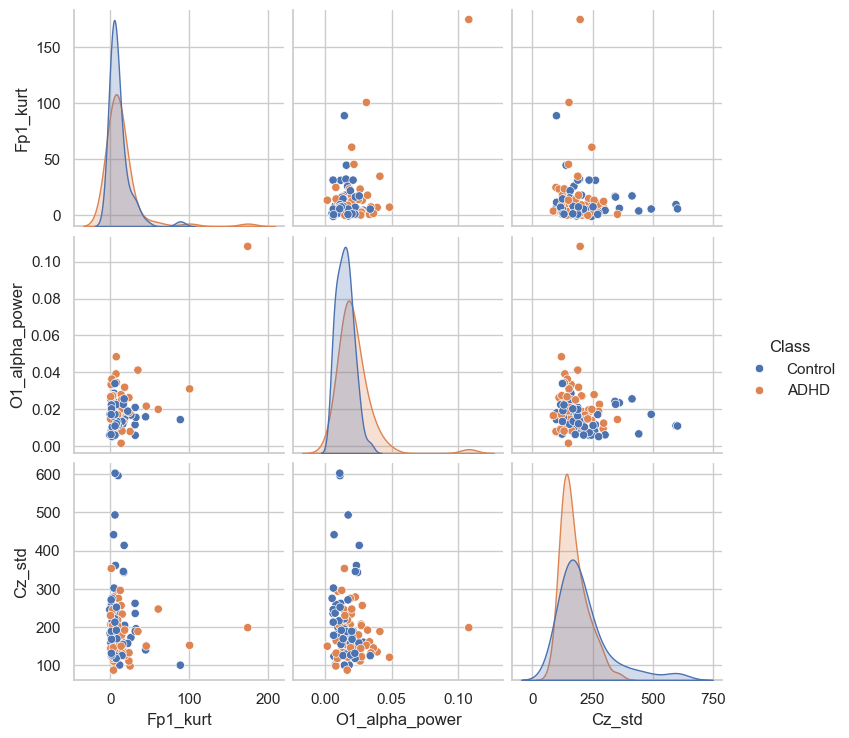

In [ ]:
cols = ["Fp1_kurt", "O1_alpha_power", "Cz_std", "Class"]
sns.pairplot(df[cols], hue="Class")

## Wnioski i preprocessing

Po zbadaniu dokładnym przebadaniu własności danych, doszedłem do wniosku, że w preprocessingu, będziemy wyciągać wyżej wymienione wskaźniki z pojedycznego testy EEG i na ich podstawie trenować modele.
Selekcja wskaźnikó zostałą wykonana na podstawie statystyk i jest wsparta załączonymi źródłami.